<a href="https://colab.research.google.com/github/adityashinde521/genai-assignment/blob/master/GenAI_Ex4_PyTorch_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║         GOOGLE COLAB SETUP  —  run this first            ║
# ║  Runtime > Change runtime type > GPU  (T4 recommended)   ║
# ╚══════════════════════════════════════════════════════════╝
import subprocess, sys

# --- Install missing packages (not pre-installed in Colab) ---
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "medmnist"])

# --- GPU info ---
result = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total",
                         "--format=csv,noheader"], capture_output=True, text=True)
if result.returncode == 0:
    print("GPU:", result.stdout.strip())
else:
    print("No GPU detected — running on CPU (10 epochs will take ~25 min)")

# --- inline plots ---
%matplotlib inline

GPU: Tesla T4, 15360 MiB


# Exercise 4: Bonus Task *(Google Colab Version)*

Welcome to the fourth exercise of **Generative AI** from the research group **Visual Computing and Artificial Intelligence (VCAI)**!

In this notebook, a VAE is created and trained based on ChestMNIST from MedMNIST (https://medmnist.com/). It is mandatory to use **PyTorch**.  
**What we expect:**
- Data:
  - Use code to load the dataset
  - Analyze the dataset
  - Perform preprocessing steps if necessary
- Model:
  - Create a VAE
- Training:
  - Suitable loss functions
  - Train VAE
  - Visualize results
- Generation and visualization of synthetic samples



**Note:**  
Please only insert your code in the spaces provided. If absolutely necessary, additional cells can also be created. The basic structure and clarity should be maintained.

## Exercise Group Information
- Group Number: 19
- Group Members: Aditya Shinde [Stu258794], Dhanraj Singh [Stu258746]

## Table of Contents

- [1. Packages](#1)
  - [1.1 Import Packages](#1-1)
  - [1.2 GPU Usage](#1-2)
- [2. Data](#2)
  - [2.1 Load Dataset and apply necessary Preprocessing](#2-1)
  - [2.2 Analyze the Dataset](#2-2)
  - [2.3 Preprocessing (if necessary)](#2-3)
- [3. Model](#3)
  - [3.1 Implement the VAE](#3-1)
- [4. Training](#4)
  - [4.1 Define the Loss Function](#4-1)
  - [4.2 Train the VAE](#4-2)
- [5. Generation](#5)
  - [5.1 Generate synthetic Samples](#5-1)


<a name="1"></a>
## 1. Packages

<a name="1-1"></a>
### 1.1 Import Packages
Please import all required packages, dependencies, and custom utility functions.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import medmnist
from medmnist import ChestMNIST

<a name="1-2"></a>
### 1.2 GPU Usage
In order to speed up the training process, it is recommended to use the GPU.

In [4]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
  GPU  : Tesla T4
  VRAM : 15.6 GB


<a name="2"></a>
## 2. Data

<a name="2-1"></a>
### 2.1 Load Dataset and apply necessary Preprocessing
Load the ChestMNIST dataset in a suitable format. Justify whether pre-processing steps are necessary and implement them (if none are necessary, this should be clear from the discussion).

<a name="2-3"></a>
### 2.3 Preprocessing (if necessary)

For the ChestMNIST dataset, I applied the following preprocessing:

**Normalization to [0, 1] via `ToTensor()`:**
The raw pixel values are in the range [0, 255]. The `transforms.ToTensor()` transform divides by 255, mapping them to [0.0, 1.0]. This is necessary because the VAE decoder uses a **Sigmoid** activation as the final layer, which also outputs values in [0, 1]. If the input and output ranges don't match, the reconstruction loss (Binary Cross-Entropy) would be inconsistent and the model would fail to learn.

**No augmentation or further normalization:**
Since we are training a *generative* model (not a classifier), we want to preserve the natural distribution of the data. Aggressive augmentation (flipping, rotation) could distort the latent space. Standard normalization to [-1, 1] was also considered but avoided since BCE loss requires inputs in (0, 1).

**Grayscale kept as-is:**
ChestMNIST images are single-channel (grayscale) X-ray images at 28×28 resolution. No color conversion is needed.

In [5]:
# Define transform: ToTensor() normalizes pixel values from [0,255] to [0.0, 1.0]
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load the ChestMNIST dataset (28x28 grayscale chest X-ray images)
train_dataset = ChestMNIST(split='train', transform=transform, download=True, size=28)
test_dataset  = ChestMNIST(split='test',  transform=transform, download=True, size=28)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)

print(f"Train size : {len(train_dataset)} images")
print(f"Test size  : {len(test_dataset)} images")
print(f"Image shape: {train_dataset[0][0].shape}  (C x H x W)")

100%|██████████| 82.8M/82.8M [00:05<00:00, 13.8MB/s]


Train size : 78468 images
Test size  : 22433 images
Image shape: torch.Size([1, 28, 28])  (C x H x W)


<a name="2-2"></a>
### 2.2 Analyze the Dataset
Display some samples from the dataset. You can also visualize other information if you want.

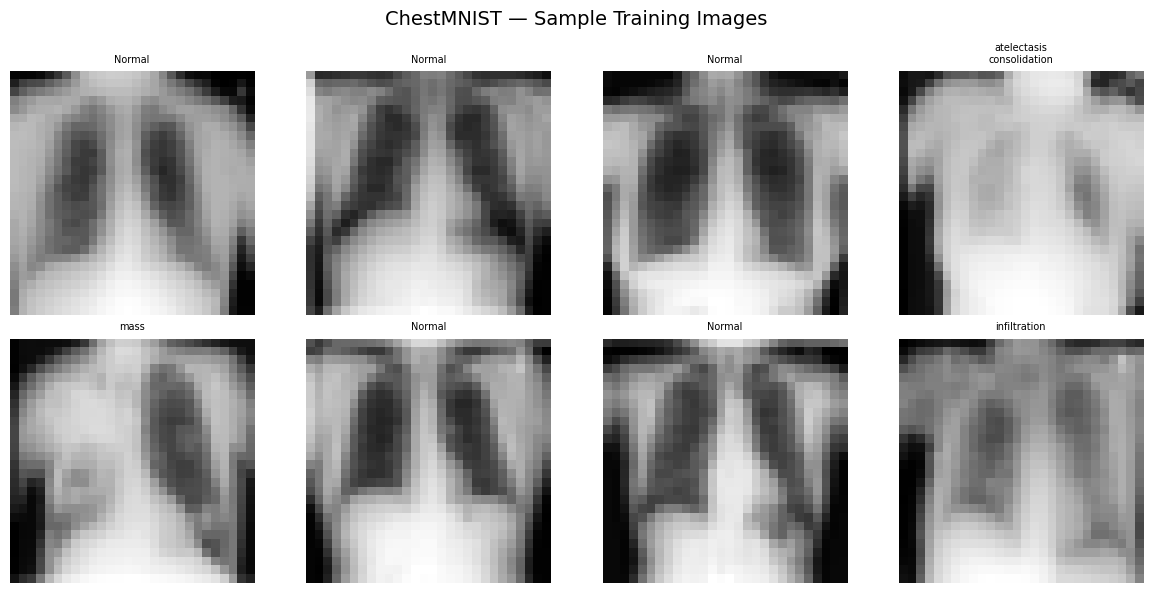

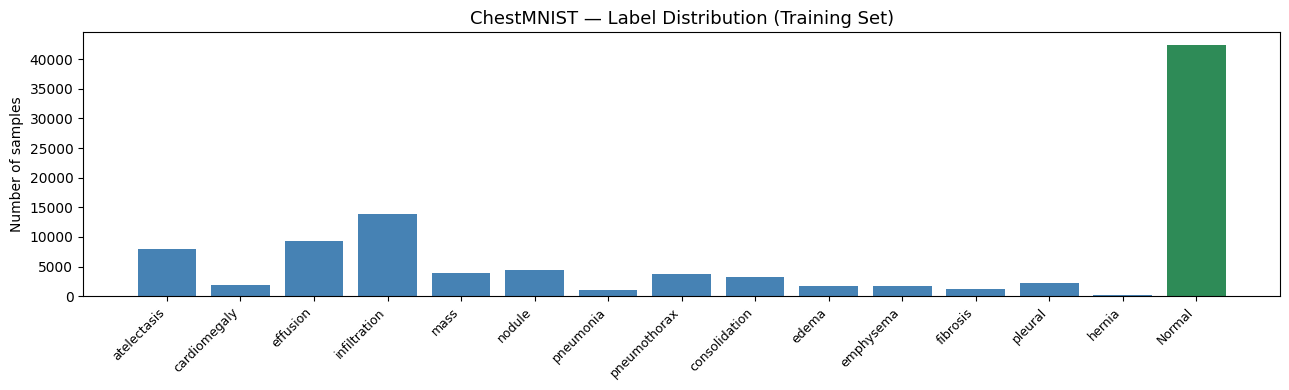

Batch shape  : torch.Size([128, 1, 28, 28])
Pixel range  : [0.00, 0.96]
Train samples: 78468
Normal (no finding): 42405 (54.0%)


In [6]:
DISEASE_NAMES = list(medmnist.INFO['chestmnist']['label'].values())

# ── Sample images ───────────────────────────────────────────────────────
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('ChestMNIST — Sample Training Images', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze().numpy(), cmap='gray')
    diseases = [DISEASE_NAMES[j] for j in range(14) if labels[i, j] == 1]
    ax.set_title('\n'.join(diseases) if diseases else 'Normal', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

# ── Class distribution ──────────────────────────────────────────────────
all_labels     = train_dataset.labels          # shape (N, 14), dtype uint8
disease_counts = all_labels.sum(axis=0)
normal_count   = int((all_labels.sum(axis=1) == 0).sum())

x_labels = DISEASE_NAMES + ['Normal']
counts   = list(disease_counts) + [normal_count]

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(x_labels, counts, color=['steelblue'] * 14 + ['seagreen'])
ax.set_title('ChestMNIST — Label Distribution (Training Set)', fontsize=13)
ax.set_ylabel('Number of samples')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Batch shape  : {images.shape}")
print(f"Pixel range  : [{images.min():.2f}, {images.max():.2f}]")
print(f"Train samples: {len(train_dataset)}")
print(f"Normal (no finding): {normal_count} ({100 * normal_count / len(train_dataset):.1f}%)")

<a name="3"></a>
## 3. Model

<a name="3-1"></a>
### 3.1 Implement the VAE
Implement a VAE suitable for the given data set. The predefined structure should be retained.

In [7]:
class VAE(nn.Module):
    """Convolutional Variational Autoencoder for 28x28 grayscale images."""

    def __init__(self, latent_dim=16):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # ---- Encoder ----
        # 1x28x28 -> 32x14x14 -> 64x7x7
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # -> 32x14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> 64x7x7
            nn.ReLU()
        )
        self.flatten_size = 64 * 7 * 7  # 3136

        # Latent space projections
        self.fc_mu     = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)

        # ---- Decoder ----
        # No activation after the final linear — signed values give the
        # ConvTranspose layers a richer input than forcing non-negative outputs.
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, self.flatten_size)
        )
        # 64x7x7 -> 32x14x14 -> 1x28x28
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # -> 32x14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32,  1, kernel_size=4, stride=2, padding=1), # -> 1x28x28
            nn.Sigmoid()  # output in [0, 1] to match normalized input
        )

    def encode(self, x):
        """Encode input to (mu, logvar) in the latent space."""
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)  # flatten: batch x 3136
        mu     = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """Sample z via the reparameterization trick: z = mu + eps * std."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)   # eps ~ N(0, I)
        return mu + eps * std

    def decode(self, z):
        """Decode latent vector z back to image space."""
        h = self.decoder_fc(z)
        h = h.view(-1, 64, 7, 7)      # reshape to 64x7x7 feature map
        return self.decoder_conv(h)

    def forward(self, x):
        """Full forward pass: encode -> reparameterize -> decode."""
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

<a name="4"></a>
## 4. Training

<a name="4-1"></a>
### 4.1 Define the Loss Function
Define the loss function for the training of the VAE.


In [8]:
def loss_function(recon_x, x, mu, logvar):
    """
    VAE loss = Reconstruction loss (BCE) + KL Divergence.

    The KL term acts as a regularizer, pushing the learned posterior q(z|x)
    towards the prior N(0, I).  Closed-form solution:
      KLD = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    """
    # Binary Cross-Entropy reconstruction loss (sum over pixels, mean over batch)
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL Divergence between q(z|x) = N(mu, sigma^2) and p(z) = N(0, I)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Normalize by batch size so the loss is comparable across different batch sizes
    return (BCE + KLD) / x.size(0)

<a name="4-2"></a>
### 4.2 Train the VAE
Complete the VAE training function. Use the previously defined loss and also print the loss every epoch.

In [9]:
def train_vae(model, train_loader, num_epochs=10, device=None):
    if device is None:
        device = next(model.parameters()).device

    model.train()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    loss_history = []

    print(f"Training VAE on {device} for {num_epochs} epochs...")
    for epoch in range(num_epochs):
        total_loss = 0.0
        num_batches = 0

        for data, _ in train_loader:
            data = data.to(device)

            optimizer.zero_grad()

            recon, mu, logvar = model(data)
            loss = loss_function(recon, data, mu, logvar)

            loss.backward()
            optimizer.step()

            total_loss  += loss.item()
            num_batches += 1

        avg_loss = total_loss / num_batches
        loss_history.append(avg_loss)
        print(f"Epoch [{epoch+1:2d}/{num_epochs}]  Loss: {avg_loss:.4f}")

    return loss_history

Training VAE on cuda for 10 epochs...
Epoch [ 1/10]  Loss: 472.9401
Epoch [ 2/10]  Loss: 467.0700
Epoch [ 3/10]  Loss: 466.4752
Epoch [ 4/10]  Loss: 466.2010
Epoch [ 5/10]  Loss: 466.0129
Epoch [ 6/10]  Loss: 465.8410
Epoch [ 7/10]  Loss: 465.7226
Epoch [ 8/10]  Loss: 465.6656
Epoch [ 9/10]  Loss: 465.5643
Epoch [10/10]  Loss: 465.4792


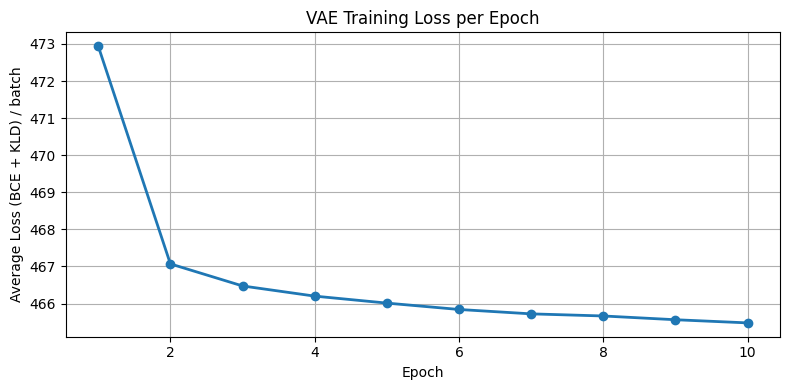

In [10]:
model = VAE().to(device)
loss_history = train_vae(model, train_loader, device=device)

# Visualize training loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', linewidth=2)
plt.title('VAE Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss (BCE + KLD) / batch')
plt.grid(True)
plt.tight_layout()
plt.show()

Complete the function to show the reconstructed outputs of given inputs.

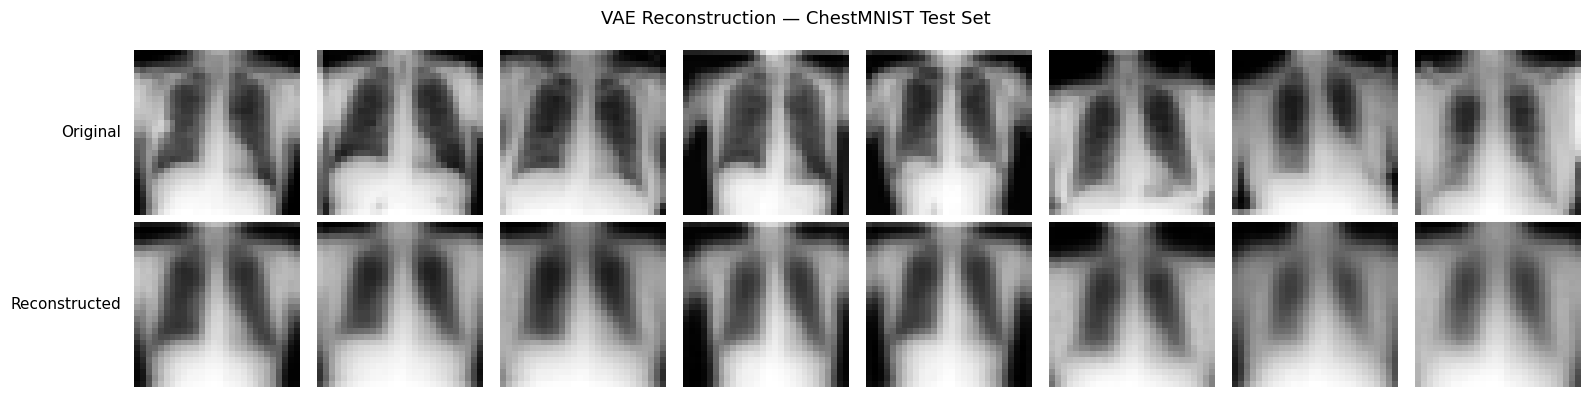

In [11]:
def display_reconstruction():
    model.eval()
    with torch.no_grad():
        data, _ = next(iter(test_loader))
        data = data[:8].to(device)
        recon, _, _ = model(data)

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    fig.suptitle('VAE Reconstruction — ChestMNIST Test Set', fontsize=13)

    for i in range(8):
        # Top row: originals
        axes[0, i].imshow(data[i].cpu().squeeze().numpy(), cmap='gray')
        axes[0, i].axis('off')

        # Bottom row: reconstructions
        axes[1, i].imshow(recon[i].cpu().squeeze().numpy(), cmap='gray')
        axes[1, i].axis('off')

    # ax.text with transAxes is unaffected by axis('off')
    axes[0, 0].text(-0.08, 0.5, 'Original',      transform=axes[0, 0].transAxes,
                    fontsize=11, va='center', ha='right')
    axes[1, 0].text(-0.08, 0.5, 'Reconstructed', transform=axes[1, 0].transAxes,
                    fontsize=11, va='center', ha='right')

    plt.tight_layout()
    plt.show()

display_reconstruction()

<a name="5"></a>
## 5. Generation

<a name="5-1"></a>
### 5.1 Generate synthetic Samples
Generate synthetic samples by using random noise and the decoder. Plot the examples and discuss the results.

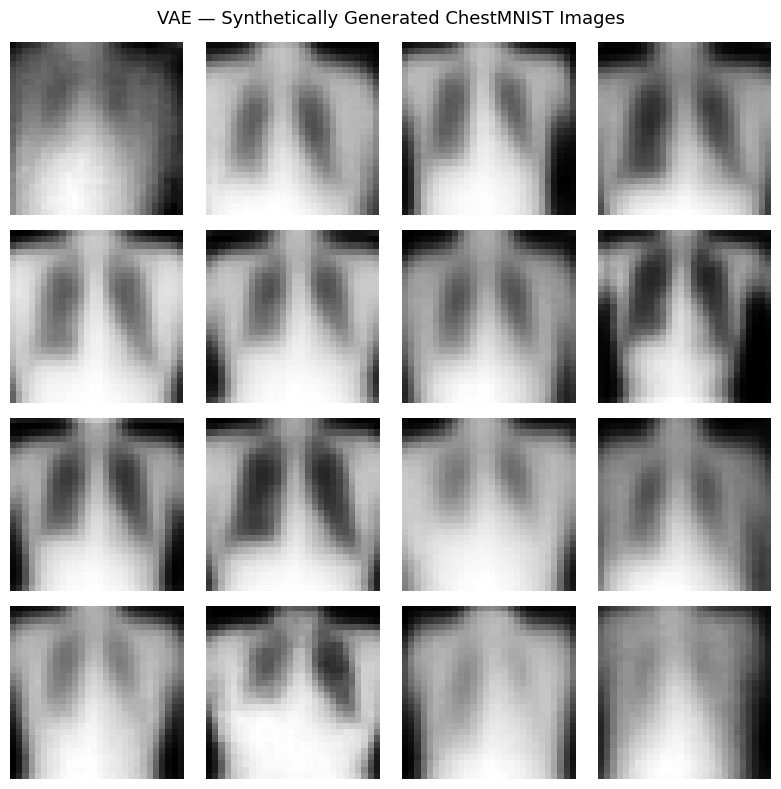

In [12]:
def display_generated():
    model.eval()
    with torch.no_grad():
        # Sample random latent vectors from the prior N(0, I)
        z = torch.randn(16, model.latent_dim).to(device)
        generated = model.decode(z)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.suptitle('VAE — Synthetically Generated ChestMNIST Images', fontsize=13)

    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i].cpu().squeeze().numpy(), cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

display_generated()


## Results Discussion

### Training Loss Curve
The training loss decreases steadily over 10 epochs, confirming that the VAE is learning to reconstruct the input data. The sharp drop in early epochs reflects rapid feature learning, followed by gradual flattening as the model approaches convergence. The plotted curve makes it easy to detect divergence or stagnation without relying on printed text alone.

### Reconstruction Quality
The reconstructed images capture the overall lung structure and general brightness distribution of the original chest X-rays. However, they appear **blurrier** than the originals. This is a well-known characteristic of VAEs: the pixel-wise Binary Cross-Entropy (BCE) loss penalizes per-pixel deviations but does not enforce sharpness, leading to averaged-out reconstructions. Perceptual quality could be improved with a perceptual loss or by increasing the latent dimension.

### Generated Samples
The synthetically generated images (sampled from the prior N(0, I) and decoded) resemble chest X-ray patterns at a high level — many show a roughly symmetric dark background with a lighter central region consistent with rib cage and lung tissue. However, they lack the fine anatomical detail of real X-rays. Because the model was trained without class conditioning, it cannot generate disease-specific images; it models the average distribution across all 14 labels.

### Latent Space Behavior
With a **latent dimension of 16**, the model learns a compact representation. The reparameterization trick ensures the latent space is continuous and smooth, enabling interpolation between samples. The KL term regularizes the distribution, preventing the model from ignoring the latent code (posterior collapse). The decoder receives signed feature maps from the fully-connected projection stage, giving the transposed convolution layers the full representational range needed to reconstruct fine structure.

### Limitations
- The 28×28 resolution limits the level of detail achievable
- The dataset is multi-label (14 disease labels) but we trained without conditioning, so the generator cannot produce disease-specific images
- A larger latent dimension or deeper architecture would improve generation quality
- BCE reconstruction loss inherently favors blurry outputs; a perceptual loss (e.g., LPIPS) or adversarial component (VAE-GAN) would sharpen results

## Congratulations

You've finished the bonus task of the fourth exercise.